### Contexto del Problema
En el ámbito médico predecir cómo avanzará una enfermedad crónica es fundamental para el tratamiento preventivo. El método tradicional para evaluar el avance de la diabetes implica medir variables clínicas iniciales y luego esperar un año entero para evaluar la progresión real del paciente.

El Problema: Esperar un año para saber si la enfermedad avanza agresivamente significa perder una ventana crítica de tiempo donde se podrían aplicar intervenciones preventivas (dieta, ejercicio, medicación).
El Objetivo: Crear un modelo de Machine Learning capaz de predecir la "progresión cuantitativa" de la diabetes un año después, basándose únicamente en mediciones basales (tomadas en el día 0), permitiendo a los médicos anticiparse a la enfermedad.


### Dataset
Utilizaremos el dataset clínico de Diabetes (load_diabetes de scikit-learn), que contiene datos de 442 pacientes.

Nota importante sobre los datos: Para este conjunto, scikit-learn entrega las variables predictoras estandarizadas (escaladas para tener media 0 y suma de cuadrados igual a 1). Esto es normal en Machine Learning médico para comparar variables de distintas escalas

### Reto Matemático
El cuerpo humano es un sistema complejo. La relación entre ciertos niveles en sangre y la progresión de la enfermedad tiene interacciones no lineales. Contrastaremos modelos lineales con algoritmos de ensamble (basados en árboles) para ver cuál captura mejor esta biología compleja.

### Variables Predictoras
- Edad (Age): Edad del paciente.
- Sexo (Sex): Sexo del paciente.
- IMC (BMI): Índice de Masa Corporal.
- PAM (BP): Presión Arterial Media.
- Colesterol_Total (S1/tc): Células T / Colesterol Total en suero.
- LDL (S2/ldl): Lipoproteínas de Baja Densidad
- HDL (S3/hdl): Lipoproteínas de Alta Densidad.
- Ratio_Colesterol (S4/tch): Colesterol total / HDL.
- Trigliceridos (S5/ltg): Logaritmo del nivel de triglicéridos en suero.
- Glucosa (S6/glu): Nivel de azúcar en sangre.

### Variable Objetivo
- Progresion (Target): Medida cuantitativa de la progresión de la enfermedad un año después de las pruebas iniciales (valores enteros entre 25 y 346)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

In [2]:
# 1. Leer los 5 ficheros anonimizados
df_diag = pd.read_csv('diagnostico_anon.csv')
df_demo = pd.read_csv('datos_demograficos_anon.csv')
df_pam  = pd.read_csv('datos_generales_paciente_pam_anon.csv')
df_lab  = pd.read_csv('laboratorio_anon.csv')
df_prog = pd.read_csv('progresion_enfermedad.csv') 

# 2. Unir los DataFrames usando 'paciente_id' como clave
df_estudio = df_demo.merge(df_diag, on='paciente_id')
df_estudio = df_estudio.merge(df_pam, on='paciente_id')
df_estudio = df_estudio.merge(df_lab, on='paciente_id')
df_estudio = df_estudio.merge(df_prog, on='paciente_id')

# 3. Calcular la Edad
# Asumiendo el año 2026 como referencia
df_estudio['edad'] = 2026 - df_estudio['nacimiento_year']

# 4. Seleccionar y ordenar solo las variables que necesitas para el estudio
columnas_estudio = [
    'edad', 
    'sexo', 
    'IMC', 
    'PAM', 
    'S1_tc', 
    'S2_ldl', 
    'S3_hdl', 
    'S4_tch', 
    'S5_ltg', 
    'S6_glu',
    'Target'
]

df = df_estudio[columnas_estudio]

# 5. Guardar Dataset Final
df.to_csv('dataset_estudio_final.csv', index=False, encoding='utf-8')

# Mostrar el resultado final
print(f"Dataset final creado con {len(df)} pacientes y {len(df.columns)} columnas.")
df.head()

Dataset final creado con 6067 pacientes y 11 columnas.


,edad,sexo,IMC,PAM,S1_tc,S2_ldl,S3_hdl,S4_tch,S5_ltg,S6_glu,Target
0,79,1,27.511,83.33,213.3,141.700000,45.8,4.657205,4.859812,123.0,106
1,65,2,41.533,121.33,366.0,131.765017,60.0,6.100000,7.021084,238.0,176
2,48,1,27.778,113.67,153.7,72.300000,56.4,2.725177,4.828314,114.0,102
3,27,2,22.633,82.33,168.0,NaN,NaN,NaN,4.394449,78.0,89
4,66,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94


In [3]:
df.describe()

,edad,sexo,IMC,PAM,S1_tc,S2_ldl,S3_hdl,S4_tch,S5_ltg,S6_glu,Target
count,6067.000000,6067.000000,4210.000000,5093.000000,5727.000000,5543.000000,5660.000000,5660.000000,5688.000000,5436.000000,6067.000000
mean,61.172573,1.494808,30.620591,96.616366,189.358642,109.028289,52.169443,3.812322,4.860196,131.851313,100.082248
std,17.206587,0.500014,6.569377,14.464445,51.332196,37.943746,14.438416,1.405731,0.528253,57.917611,24.706266
min,2.000000,1.000000,2.703000,8.330000,61.000000,5.101011,13.700000,1.003963,3.374169,38.000000,25.000000
25%,50.000000,1.000000,26.220500,89.330000,155.000000,82.951243,42.000000,2.961538,4.510860,100.000000,84.000000
50%,63.000000,1.000000,29.959000,96.670000,187.000000,107.600000,50.000000,3.604957,4.828314,119.000000,99.000000
75%,73.500000,2.000000,34.195500,103.330000,219.495000,134.077643,60.100000,4.420000,5.176150,142.000000,115.000000
max,101.000000,2.000000,101.000000,546.670000,991.000000,277.300000,128.000000,38.115385,8.511175,836.000000,346.000000


In [4]:
df.shape

(6067, 11)

### Valores nulos

In [5]:
# Verificar nulos
print("Recuento de Valores Nulos")
print(df.isnull().sum())

Recuento de Valores Nulos
edad         0
sexo         0
IMC       1857
PAM        974
S1_tc      340
S2_ldl     524
S3_hdl     407
S4_tch     407
S5_ltg     379
S6_glu     631
Target       0
dtype: int64


In [6]:
# Eliminar todos los registros que tienen nulos
df = df.dropna()
print(f"Filas restantes: {df.shape[0]}")

Filas restantes: 3722


### Variable objetivo

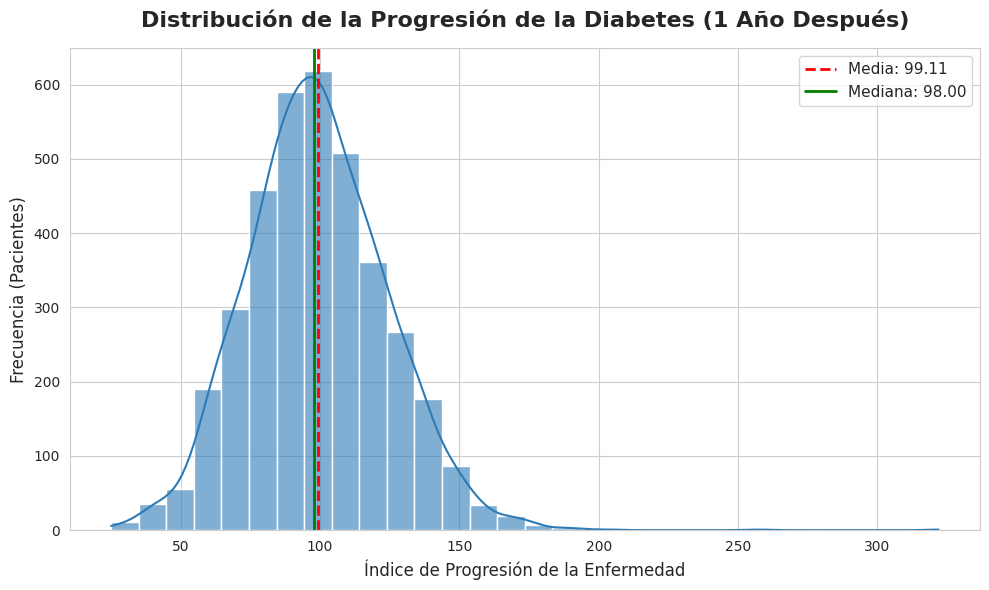

Asimetría (Skewness): 0.44
-> La distribución es bastante SIMÉTRICA (Cercana a Normal).


In [7]:
# Configuración de estilo
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# 1. Crear el Histograma con la curva de densidad (KDE)
sns.histplot(data=df, x='Target', kde=True, color='#2c7bb6', bins=30, alpha=0.6)

# 2. Calcular Media y Mediana
media = df['Target'].mean()
mediana = df['Target'].median()

# 3. Dibujar líneas verticales
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')

# 4. Títulos y Etiquetas Profesionales
plt.title('Distribución de la Progresión de la Diabetes (1 Año Después)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Índice de Progresión de la Enfermedad', fontsize=12)
plt.ylabel('Frecuencia (Pacientes)', fontsize=12)

# 5. Añadir leyenda
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Asimetría (Skewness): {df['Target'].skew():.2f}")
if -0.5 < df['Target'].skew() < 0.5:
    print("-> La distribución es bastante SIMÉTRICA (Cercana a Normal).")
else:
    print("-> La distribución está SESGADA (No es perfectamente Normal).")

### Correlación

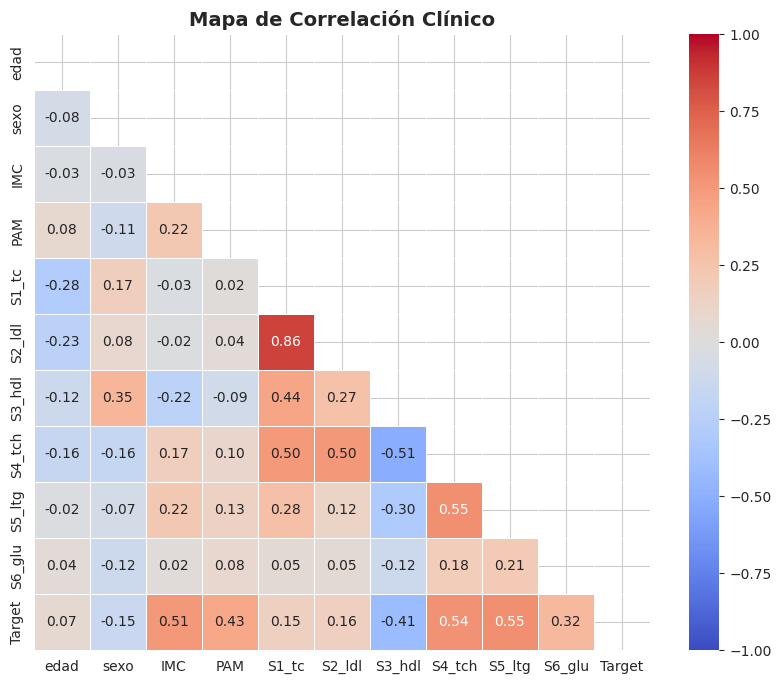

In [8]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmax=1, vmin=-1, linewidths=0.5, square=True)

plt.title('Mapa de Correlación Clínico', fontsize=14, fontweight='bold')
plt.show()

### PREPARACIÓN DE LOS DATOS PARA EL ENTRENAMIENTO DEL MODELO

In [9]:
# Definir X e y
X = df.drop('Target', axis=1)
feature_names = X.columns
y = df['Target']

In [10]:
# Train y Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### ESCALADO

In [11]:
scaler = StandardScaler()

# 1. Aprender la escala SOLO de los datos de entrenamiento y transformarlos
X_train_scaled = scaler.fit_transform(X_train)

# 2. Transformar los datos de test usando la regla aprendida
X_test_scaled = scaler.transform(X_test)

In [12]:
# KFold
cv_regresion = KFold(n_splits=5, shuffle=True, random_state=42)

In [13]:
historial_modelos = []

In [14]:
def calcular_metricas(modelo, X_test, y_test, nombre_modelo):
    y_pred = modelo.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return {'Modelo': nombre_modelo, 'MAE': mae, 'RMSE': rmse, 'R2 (Calidad)': r2}

In [15]:
def plot_real_vs_pred(model, X_test, y_test, model_name, color='blue'):
    y_pred = model.predict(X_test)
    plt.figure(figsize=(8, 8))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color=color, s=60)
    m = max(y_test.max(), y_pred.max())
    plt.plot([0, m], [0, m], 'r--', lw=2, label='Predicción Perfecta')
    plt.title(f'Validación: {model_name} (Real vs Estimado)', fontsize=14, fontweight='bold')
    plt.xlabel('Progresión Real', fontsize=12)
    plt.ylabel(f'Predicción {model_name}', fontsize=12)
    plt.legend()
    plt.axis('square')
    plt.show()

In [16]:
def get_top_features(model, feature_names, top_n=10):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        total_importance = importances.sum()
        importances_normalized = importances / total_importance if total_importance > 0 else importances
        feat_imp = pd.Series(importances_normalized, index=feature_names).sort_values(ascending=False)
        return feat_imp.head(top_n)
    return pd.Series()

In [17]:
def plot_feature_importance(model, feature_names, model_name, palette='viridis'):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
        plt.figure(figsize=(10, 6))
        sns.barplot(x=feat_imp.values, y=feat_imp.index, palette=palette)
        plt.title(f'Ranking de Variables Clínicas: {model_name}', fontsize=14, fontweight='bold')
        plt.xlabel('Importancia Relativa', fontsize=12)
        plt.ylabel('Marcadores Clínicos', fontsize=12)
        plt.show()

In [18]:
def plot_residuals(model, X_test, y_test, model_name, color='purple'):
    y_pred = model.predict(X_test)
    residuos = y_test - y_pred
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_test, y=residuos, color=color, alpha=0.6, s=60)
    plt.axhline(0, color='black', linestyle='--', lw=2, label='Error Cero')
    plt.axhline(30, color='gray', linestyle=':', alpha=0.5)
    plt.axhline(-30, color='gray', linestyle=':', alpha=0.5)
    plt.title(f'Diagnóstico de Residuos: {model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Progresión REAL', fontsize=12)
    plt.ylabel('Error (Real - Predicho)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

### RANDOM FOREST

In [19]:
dict_params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [2, 4],
    "max_features": ["sqrt", 1.0],
    "criterion": ["squared_error"]
}

In [20]:
grid_rf = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                       param_grid=dict_params, cv=cv_regresion, n_jobs=-1,
                       verbose=1, scoring='r2', return_train_score=True)

In [21]:
print("Entrenando Random Forest")
grid_rf.fit(X_train_scaled, y_train)
best_rf = grid_rf.best_estimator_
print(f"\nMejores parámetros: {grid_rf.best_params_}")

Entrenando Random Forest
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Mejores parámetros: {'criterion': 'squared_error', 'max_depth': 10, 'max_features': 1.0, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


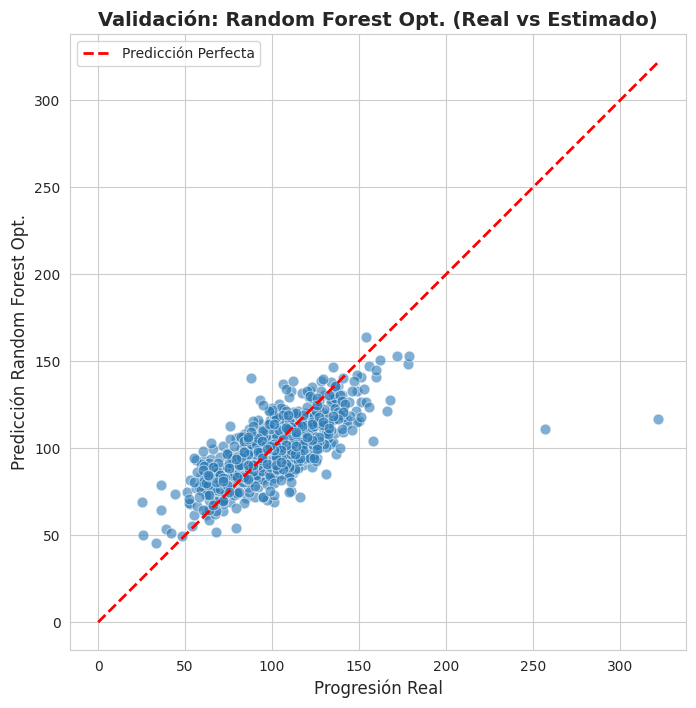

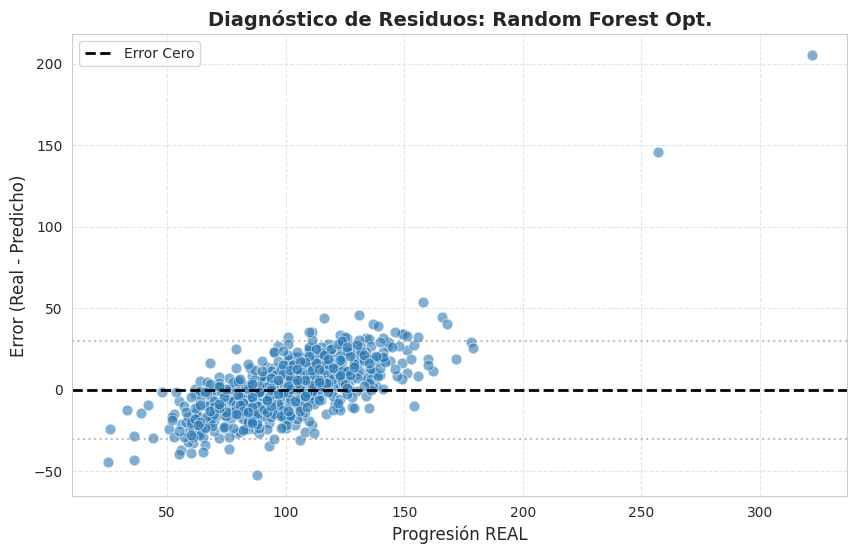

/tmp/ipykernel_20779/3518772632.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette=palette)


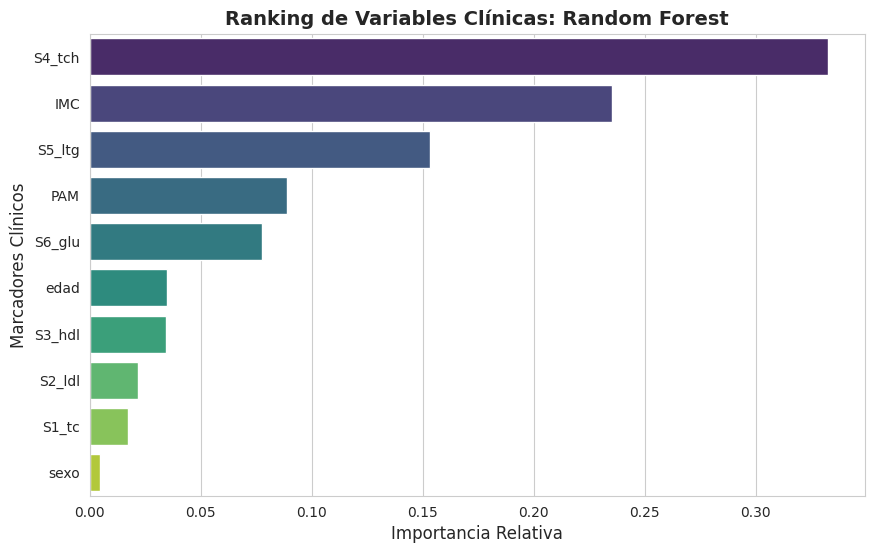

Top Variables: S4_tch    0.332413
IMC       0.235203
S5_ltg    0.153442
PAM       0.088880
S6_glu    0.077726
dtype: float64


In [22]:
# Visualizaciones y Métricas
plot_real_vs_pred(best_rf, X_test_scaled, y_test, "Random Forest Opt.", color='#2c7bb6')
plot_residuals(best_rf, X_test_scaled, y_test, "Random Forest Opt.", color='#2c7bb6')
plot_feature_importance(best_rf, X_train.columns, "Random Forest", palette='viridis')
print("Top Variables:", get_top_features(best_rf, feature_names, top_n=5))

In [23]:
metricas_rf = calcular_metricas(best_rf, X_test_scaled, y_test, "Random Forest")
historial_modelos.append(metricas_rf)

### XGBoost

In [24]:
dict_params_xgb = {
    "n_estimators": [50, 100], 
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8],
    "objective": ['reg:squarederror']
}

In [25]:
grid_xgb = GridSearchCV(estimator=XGBRegressor(random_state=42, n_jobs=-1),
                        param_grid=dict_params_xgb, cv=cv_regresion, verbose=1, scoring='r2')

In [26]:
print("Entrenando XGBoost")
grid_xgb.fit(X_train_scaled, y_train)
best_xgb = grid_xgb.best_estimator_

print(f"\nMejores parámetros XGB: {grid_xgb.best_params_}")

Entrenando XGBoost
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Mejores parámetros XGB: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100, 'objective': 'reg:squarederror', 'subsample': 0.8}


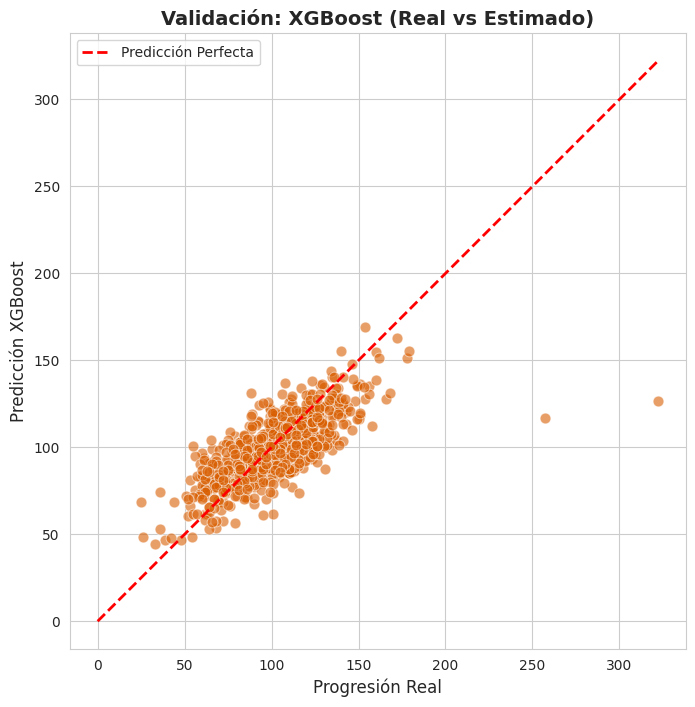

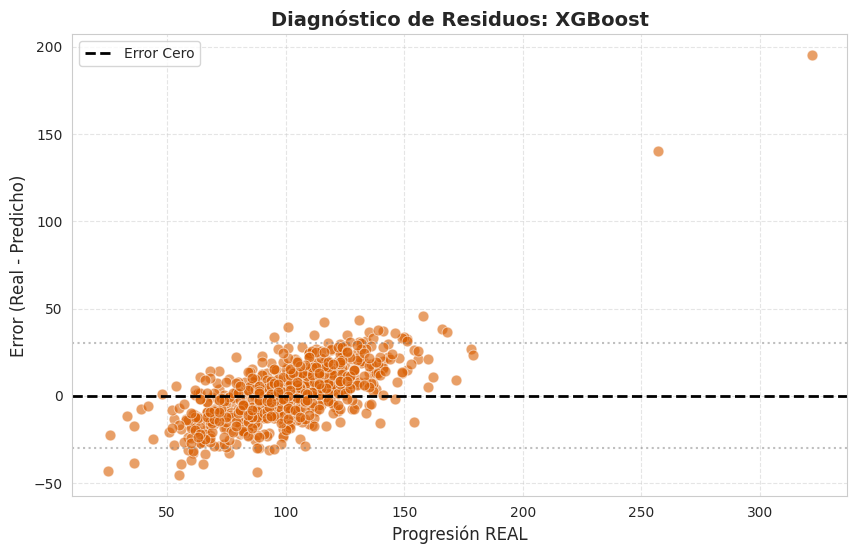

/tmp/ipykernel_20779/3518772632.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette=palette)


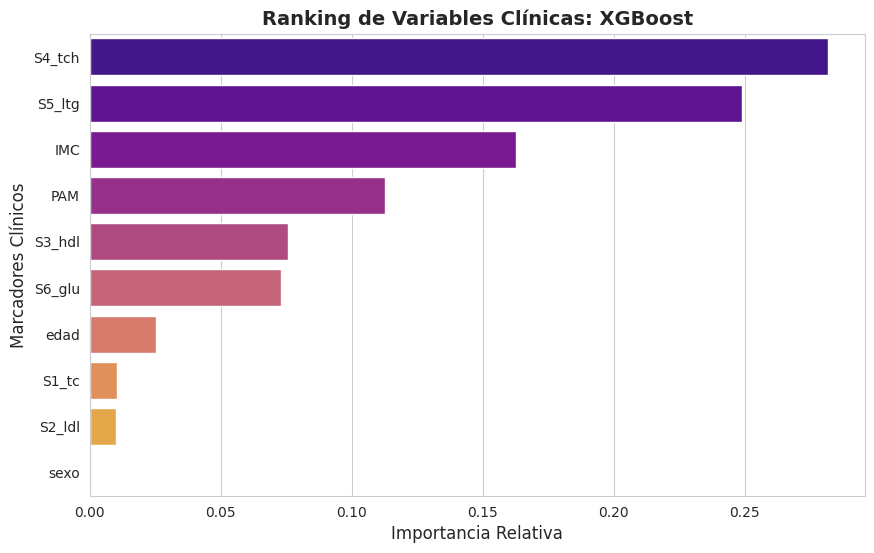

In [27]:
plot_real_vs_pred(best_xgb, X_test_scaled, y_test, "XGBoost", color='#d95f02')
plot_residuals(best_xgb, X_test_scaled, y_test, "XGBoost", color='#d95f02')
plot_feature_importance(best_xgb, X_train.columns, "XGBoost", palette='plasma')

metricas_xgb = calcular_metricas(best_xgb, X_test_scaled, y_test, "XGBoost")
historial_modelos.append(metricas_xgb)

### REGRESIÓN LINEAL

In [28]:
dict_params_lr = {
    "alpha": [0.01, 0.1, 1.0, 10.0, 100.0], # Fuerza de la penalización para evitar sobreajuste
    "solver": ['auto', 'svd', 'cholesky', 'saga'] # Algoritmos de resolución matemática
}

In [29]:
grid_lr = GridSearchCV(
    estimator=Ridge(random_state=42, max_iter=10000),
    param_grid=dict_params_lr,
    cv=cv_regresion,
    n_jobs=-1,
    verbose=1,
    scoring='r2',
    return_train_score=True
)

In [30]:
print("Entrenando Regresión Lineal Regularizada")
grid_lr.fit(X_train_scaled, y_train)

best_lr = grid_lr.best_estimator_

print(f"\nMejores parámetros Regresión Lineal: {grid_lr.best_params_}")

Entrenando Regresión Lineal Regularizada
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Mejores parámetros Regresión Lineal: {'alpha': 10.0, 'solver': 'auto'}


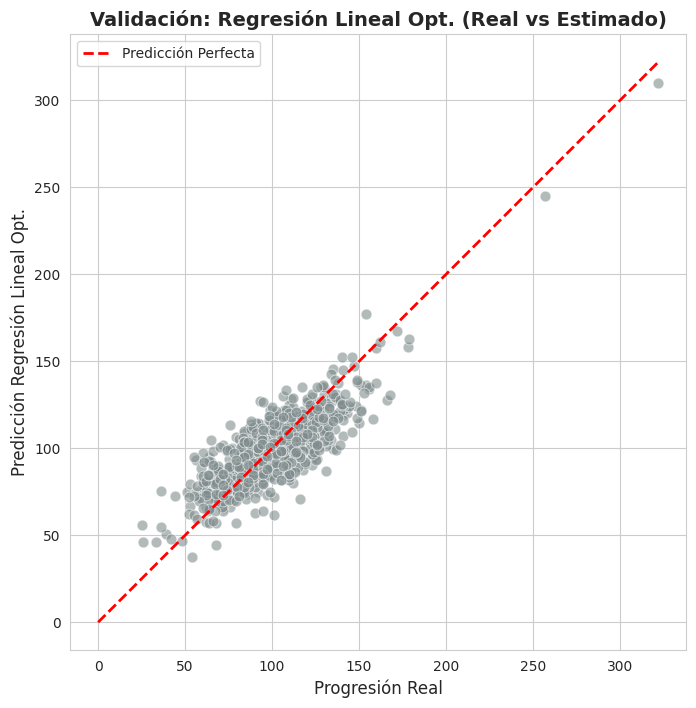

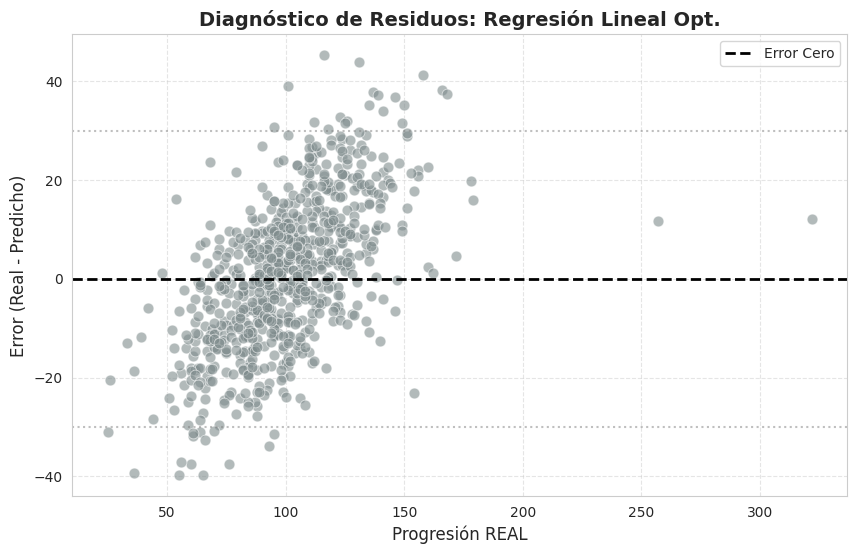

/tmp/ipykernel_20779/4185019794.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coeficientes.values, y=coeficientes.index, palette='RdBu_r')


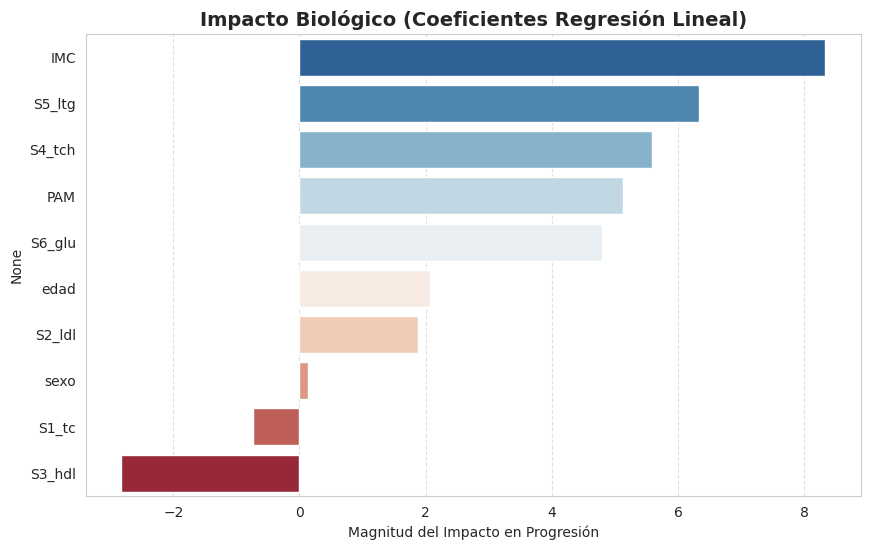

In [31]:
# 1. Gráfico Realidad vs. Predicción
plot_real_vs_pred(best_lr, X_test_scaled, y_test, "Regresión Lineal Opt.", color='#7f8c8d')

# 2. Gráfico para diagnosticar residuos
plot_residuals(best_lr, X_test_scaled, y_test, "Regresión Lineal Opt.", color='#7f8c8d')

# 3. Análisis de Coeficientes (Equivalente a la Importancia de Características)
# Nota: Los modelos lineales usan '.coef_' en lugar de '.feature_importances_'
coeficientes = pd.Series(best_lr.coef_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=coeficientes.values, y=coeficientes.index, palette='RdBu_r')
plt.title('Impacto Biológico (Coeficientes Regresión Lineal)', fontsize=14, fontweight='bold')
plt.xlabel('Magnitud del Impacto en Progresión')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

metricas_lr = calcular_metricas(best_lr, X_test_scaled, y_test, "Regresión Lineal Opt.")

historial_modelos.append(metricas_lr)

### RESULTADOS FINALES

In [32]:
df_resultados = pd.DataFrame(historial_modelos).sort_values(by='R2 (Calidad)', ascending=False)
print("\nRESULTADO FINAL")
df_resultados


RESULTADO FINAL


,Modelo,MAE,RMSE,R2 (Calidad)
2,Regresión Lineal Opt.,12.046568,15.026896,0.670031
1,XGBoost,12.795852,17.768052,0.538667
0,Random Forest,13.068317,18.283337,0.511521
